In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "META", "NVDA"]

data = yf.download(tickers, start="2018-01-01", end="2024-01-01")



In [2]:
prices = data["Close"]
prices.head()

Ticker,AAPL,AMZN,GOOGL,META,MSFT,NVDA
Date,,,,,,
2018-01-02,40.304176,59.450500,53.220631,180.007385,78.870377,4.928267
2018-01-03,40.297153,60.209999,54.128632,183.232086,79.237396,5.252615
2018-01-04,40.484333,60.479500,54.338886,182.894730,79.934807,5.280303
2018-01-05,40.945263,61.457001,55.059433,185.395126,80.925865,5.325050
2018-01-08,40.793175,62.343498,55.253826,186.813980,81.008453,5.488213


In [4]:
# 计算月度收益（用21个交易日 ≈ 1个月）
monthly_returns = prices.pct_change(21)

# 12个月动量（252交易日 ≈ 1年）
momentum = prices.pct_change(252)

momentum.tail()

Ticker,AAPL,AMZN,GOOGL,META,MSFT,NVDA
Date,,,,,,
2023-12-22,0.437299,0.768123,0.579482,1.950818,0.546052,1.960528
2023-12-26,0.468117,0.830887,0.612580,2.029627,0.586893,2.214086
2023-12-27,0.472999,0.798710,0.573125,2.031430,0.580810,2.251278
2023-12-28,0.497055,0.847062,0.604646,2.065709,0.597770,2.508532
2023-12-29,0.536069,0.857003,0.623925,2.061408,0.617594,2.529779


In [6]:
# 选择一个时间点（先测试）
date = momentum.index[-1]

momentum_on_date = momentum.loc[date]

# 排序（从高到低）
ranked = momentum_on_date.sort_values(ascending=False)

ranked

Ticker
NVDA     2.529779
META     2.061408
AMZN     0.857003
GOOGL    0.623925
MSFT     0.617594
AAPL     0.536069
Name: 2023-12-29 00:00:00, dtype: float64

In [7]:
top_stocks = ranked.head(2)
top_stocks

Ticker
NVDA    2.529779
META    2.061408
Name: 2023-12-29 00:00:00, dtype: float64

In [13]:
portfolio_returns = []
portfolio_dates = []

dates = momentum.index

for i in range(252, len(dates)-21):
    date = dates[i]
    
    signal = momentum.loc[date]
    ranked = signal.sort_values(ascending=False)
    top_stocks = ranked.head(2).index
    
    next_returns = monthly_returns.loc[dates[i+1], top_stocks]
    
    portfolio_returns.append(next_returns.mean())
    portfolio_dates.append(dates[i+1])   # 👈 关键

portfolio_returns = pd.Series(portfolio_returns, index=portfolio_dates)

<Axes: title={'center': 'Momentum Strategy'}>

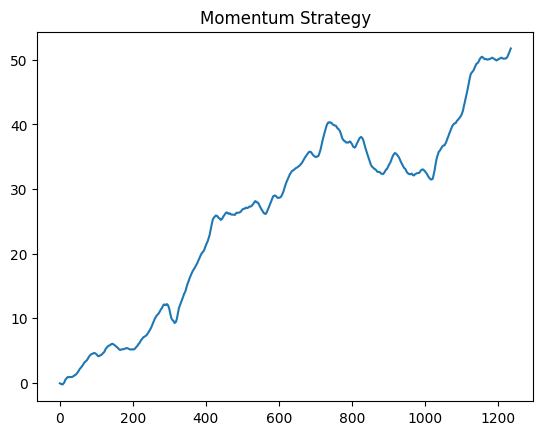

In [9]:
portfolio_returns.cumsum().plot(title="Momentum Strategy")

[*********************100%***********************]  1 of 1 completed


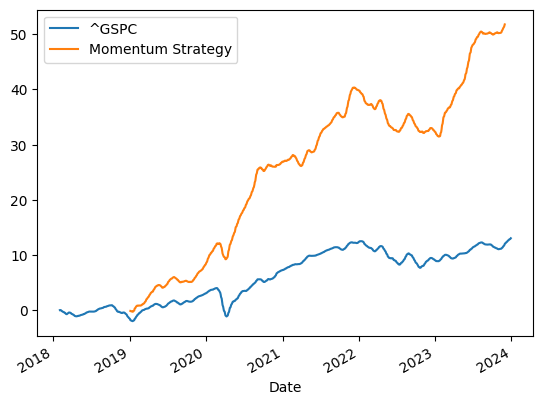

In [14]:
sp500 = yf.download("^GSPC", start="2018-01-01", end="2024-01-01")
sp500_returns = sp500["Close"].pct_change(21)

sp500_returns.cumsum().plot(label="S&P 500")
portfolio_returns.cumsum().plot(label="Momentum Strategy")

import matplotlib.pyplot as plt
plt.legend()
plt.show()

In [28]:
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

tables = pd.read_html(url)
sp500_table = tables[0]

tickers = sp500_table["Symbol"].tolist()

# 处理特殊符号（很关键）
tickers = [ticker.replace(".", "-") for ticker in tickers]

tickers[:10]

URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1028)>

In [27]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [29]:
tickers = [
    "AAPL","MSFT","GOOGL","AMZN","META","NVDA","TSLA","BRK-B","UNH","JNJ",
    "XOM","JPM","V","PG","MA","HD","CVX","ABBV","PEP","KO",
    "MRK","COST","AVGO","ADBE","CSCO","WMT","MCD","CRM","ABT","TMO",
    "ACN","LIN","DHR","NFLX","AMD","ORCL","INTC","QCOM","TXN","HON",
    "LOW","UPS","MS","GS","AMAT","SPGI","INTU","NOW","PLD","BLK"
]

In [30]:
data = yf.download(tickers, start="2018-01-01", end="2024-01-01")

prices = data["Close"]

[*********************100%***********************]  50 of 50 completed


In [31]:
prices = prices.dropna(axis=1, how="any")

In [32]:
# 月度收益
monthly_returns = prices.pct_change(21)

# 12个月动量
momentum = prices.pct_change(252)

In [33]:
# 横截面标准化（每一天）
momentum_z = momentum.sub(momentum.mean(axis=1), axis=0) \
                     .div(momentum.std(axis=1), axis=0)

In [34]:
portfolio_returns = []
portfolio_dates = []

dates = momentum_z.index

for i in range(252, len(dates)-21):
    date = dates[i]
    
    signal = momentum_z.loc[date].dropna()
    
    # 排序
    ranked = signal.sort_values(ascending=False)
    
    # 选 top 20%
    n = int(len(ranked) * 0.2)
    top_stocks = ranked.head(n).index
    
    # 下期收益
    next_returns = monthly_returns.loc[dates[i+1], top_stocks]
    
    portfolio_returns.append(next_returns.mean())
    portfolio_dates.append(dates[i+1])

portfolio_returns = pd.Series(portfolio_returns, index=portfolio_dates)

[*********************100%***********************]  1 of 1 completed


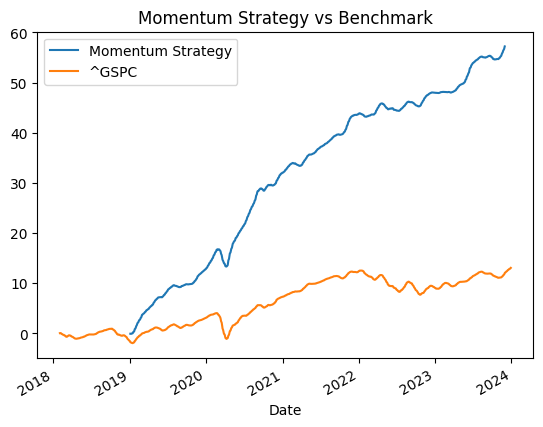

In [38]:
sp500 = yf.download("^GSPC", start="2018-01-01", end="2024-01-01")
sp500_returns = sp500["Close"].pct_change(21)

import matplotlib.pyplot as plt

fig, ax = plt.subplots()

portfolio_returns.cumsum().plot(ax=ax, label="Momentum Strategy")
sp500_returns.cumsum().plot(ax=ax, label="S&P 500")

ax.legend()
ax.set_title("Momentum Strategy vs Benchmark")

plt.show()

In [40]:
sharpe = portfolio_returns.mean() / portfolio_returns.std() * (12 ** 0.5)
print("Sharpe Ratio:", sharpe)

Sharpe Ratio: 2.3772930023214625
